# Exact Green's Function on Lattice Points Inside a Rectangular Complex t Tube

This notebook evaluates `G_exact` on a regular complex `t` lattice inside a rectangular tube around the real axis, then plots smooth contours for the absolute values of real and imaginary parts of selected Green's function entries.


In [7]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt

from t_interpolation_workflow import compute_exact_t

In [8]:
# Same base parameter setup as AAA_t_test3.
beta = 20.0
Ns = 2
Nw = 4 * int(beta)
Mat_fre = (2 * np.linspace(0, Nw - 1, Nw) + 1) * np.pi / beta
wn = np.append(-np.flip(Mat_fre), Mat_fre)

U = 1.0
T = 1.0
Nt = 1001
epsilon = 1e-4

# Rectangular tube setup: Re(t) in [-T, T], |Im(t)| <= tube_delta.
tube_delta = 0.5
tube_real_window = (-T, T)

# Lattice resolution for the smooth contour plots.
N_real_lattice = 501
N_imag_lattice = 501

wn_id = [Nw - 1, Nw - 2, Nw - 3, Nw - 4, Nw - 5]
n_plot = wn_id[0]
print("plotting Matsubara index:", n_plot, "omega:", wn[n_plot])


plotting Matsubara index: 79 omega: -0.15707963267948966


In [9]:
def inside_delta_tube(z, real_window, delta):
    lo, hi = real_window
    z = np.asarray(z)
    return (z.real >= lo) & (z.real <= hi) & (np.abs(z.imag) <= delta)


def make_tube_lattice(real_window, delta, n_real, n_imag):
    lo, hi = real_window
    real_axis = np.linspace(lo, hi, n_real)
    imag_axis = np.linspace(-delta, delta, n_imag)
    real_grid, imag_grid = np.meshgrid(real_axis, imag_axis)
    z_grid = real_grid + 1j * imag_grid
    mask = inside_delta_tube(z_grid, real_window, delta)
    return real_grid, imag_grid, z_grid, mask


def tube_boundary(real_window, delta):
    lo, hi = real_window
    return np.array([
        lo - 1j * delta,
        hi - 1j * delta,
        hi + 1j * delta,
        lo + 1j * delta,
        lo - 1j * delta,
    ])


def lattice_field(values_inside, mask):
    field = np.full(mask.shape, np.nan, dtype=float)
    field[mask] = values_inside
    return field


In [10]:
real_grid, imag_grid, t_grid, tube_mask = make_tube_lattice(
    tube_real_window,
    tube_delta,
    N_real_lattice,
    N_imag_lattice,
)
t_lattice = t_grid[tube_mask]
G_exact_lattice = compute_exact_t(t_lattice, wn, U, beta)
boundary = tube_boundary(tube_real_window, tube_delta)

print("lattice grid shape:", t_grid.shape)
print("tube lattice points:", t_lattice.shape)
print("G_exact_lattice shape:", G_exact_lattice.shape)
print("max |Im(t)|:", np.max(np.abs(t_lattice.imag)))
print("real range:", (t_lattice.real.min(), t_lattice.real.max()))


/Users/yzhu4/Desktop/projects/rational_interpolation_hubbard/Many_body_interpolation/hubbard_dimer/t_interpolation/../analytic_solution.py:107: RuntimeWarning: divide by zero encountered in scalar divide
  G[:, i, j] = factor1/ (2 * a**2) * (sign* alpha_plus_sq / denom1 + alpha_minus_sq / denom2) + factor2/ (2 * a**2) * (alpha_plus_sq / denom3 +sign * alpha_minus_sq / denom4)+ factor3*3/4*(1/fdenom1+sign/fdenom3) +factor4*3/4*(sign/fdenom2+1/fdenom4)
/Users/yzhu4/Desktop/projects/rational_interpolation_hubbard/Many_body_interpolation/hubbard_dimer/t_interpolation/../analytic_solution.py:107: RuntimeWarning: invalid value encountered in multiply
  G[:, i, j] = factor1/ (2 * a**2) * (sign* alpha_plus_sq / denom1 + alpha_minus_sq / denom2) + factor2/ (2 * a**2) * (alpha_plus_sq / denom3 +sign * alpha_minus_sq / denom4)+ factor3*3/4*(1/fdenom1+sign/fdenom3) +factor4*3/4*(sign/fdenom2+1/fdenom4)


lattice grid shape: (501, 501)
tube lattice points: (251001,)
G_exact_lattice shape: (251001, 160, 2, 2)
max |Im(t)|: 0.5
real range: (np.float64(-1.0), np.float64(1.0))


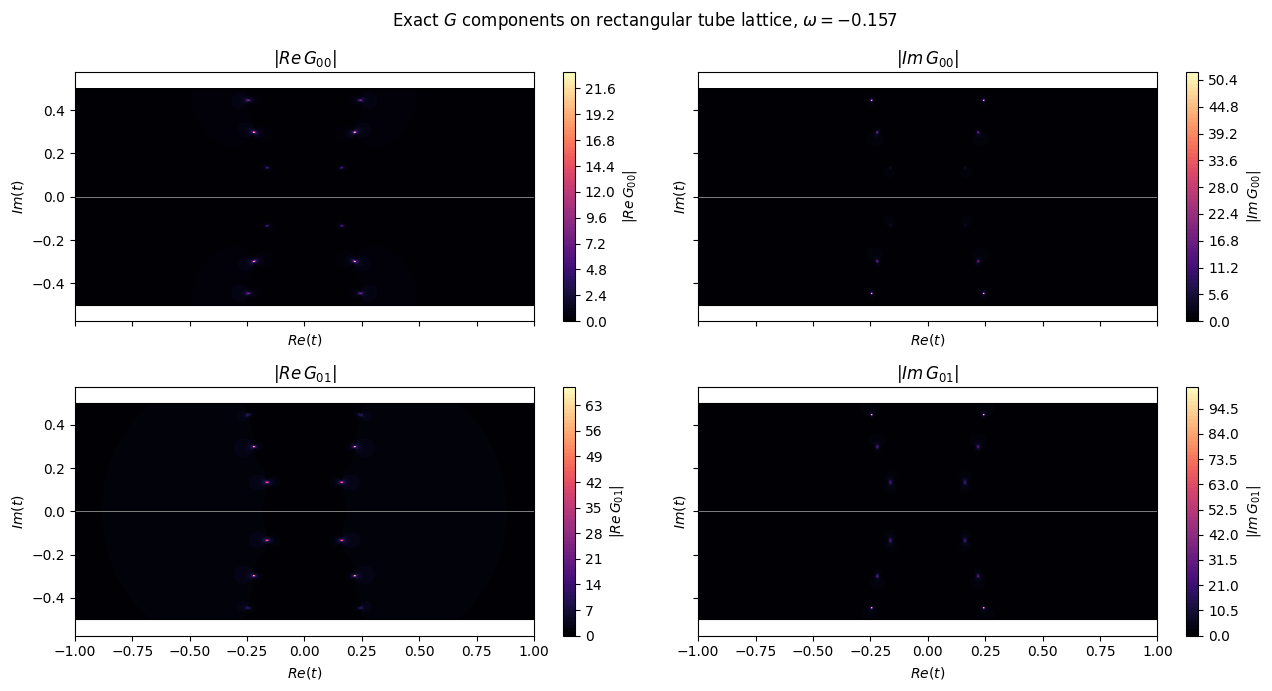

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
components = [
    (0, 0, np.real, r"$|Re\,G_{00}|$"),
    (0, 0, np.imag, r"$|Im\,G_{00}|$"),
    (0, 1, np.real, r"$|Re\,G_{01}|$"),
    (0, 1, np.imag, r"$|Im\,G_{01}|$"),
]

for ax, (i, j, part, title) in zip(axes.ravel(), components):
    values = np.abs(part(G_exact_lattice[:, n_plot, i, j]))
    field = lattice_field(values, tube_mask)
    cf = ax.contourf(real_grid, imag_grid, field, levels=80, cmap="magma")
    ax.plot(boundary.real, boundary.imag, color="k", linewidth=0.8)
    ax.axhline(0, color="0.5", linewidth=0.7)
    ax.set_ylim(-1.15 * tube_delta, 1.15 * tube_delta)
    ax.set_title(title)
    ax.set_xlabel(r"$Re(t)$")
    ax.set_ylabel(r"$Im(t)$")
    fig.colorbar(cf, ax=ax, label=title)

fig.suptitle(rf"Exact $G$ components on rectangular tube lattice, $\omega={wn[n_plot]:.3g}$")
fig.tight_layout()
plt.show()


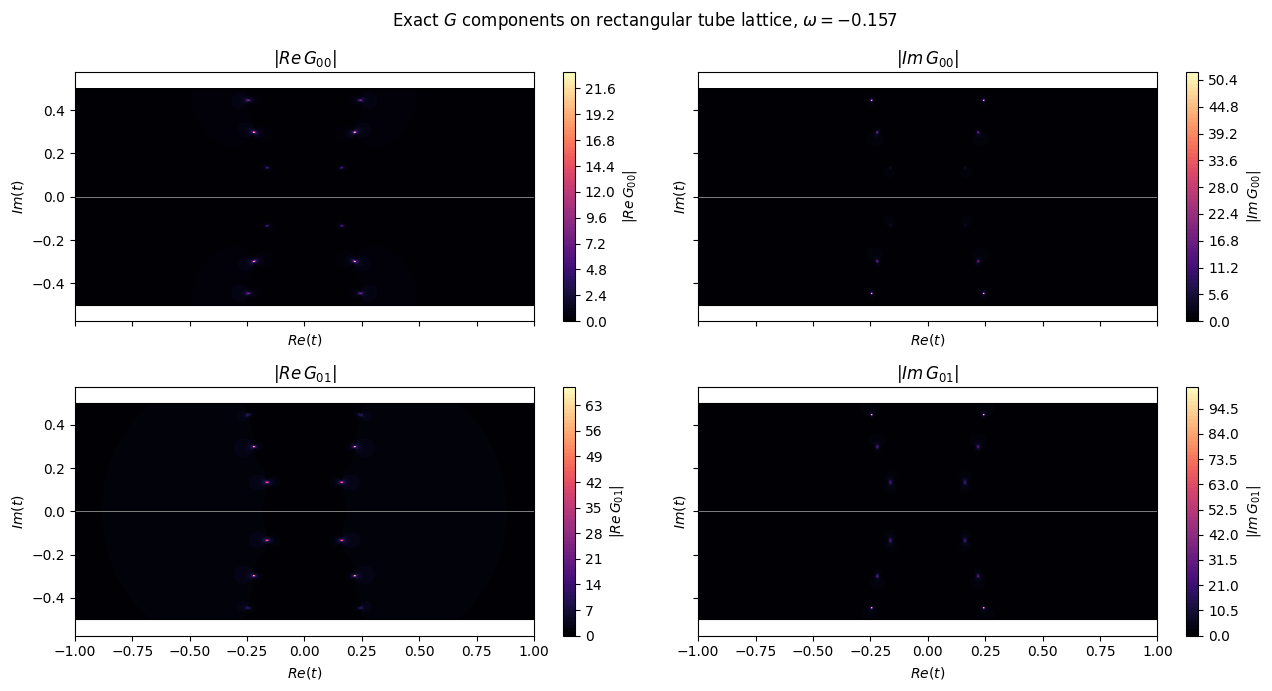

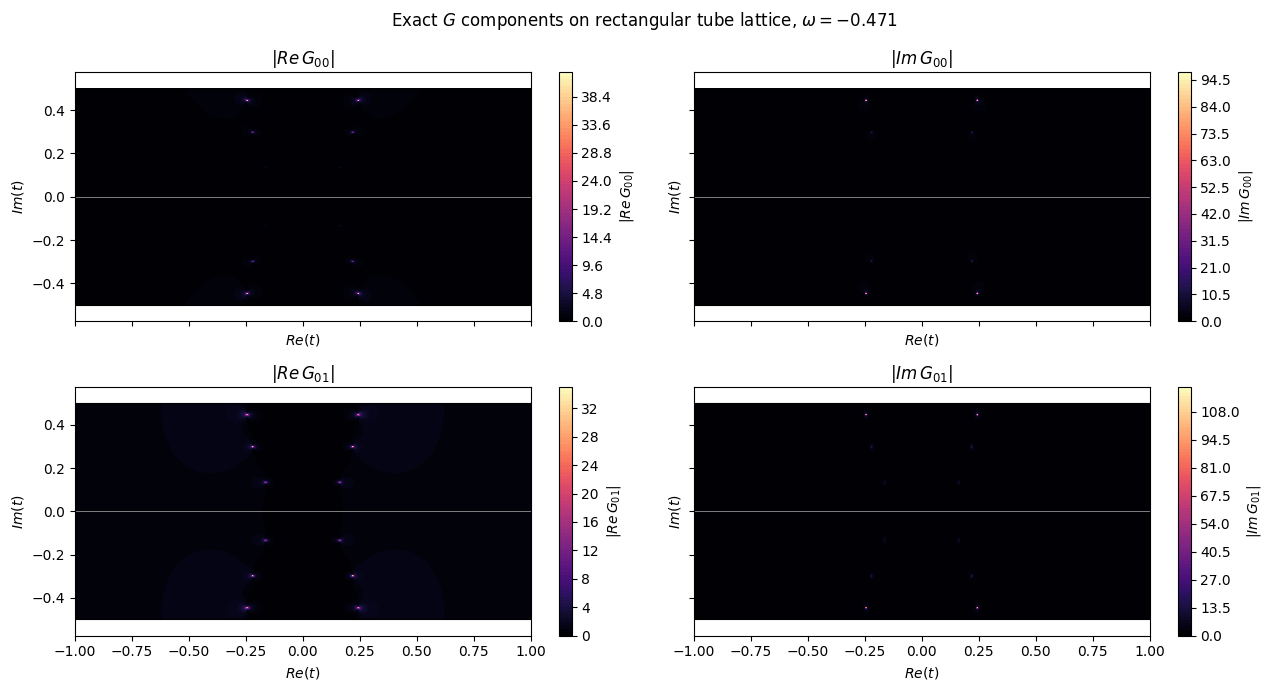

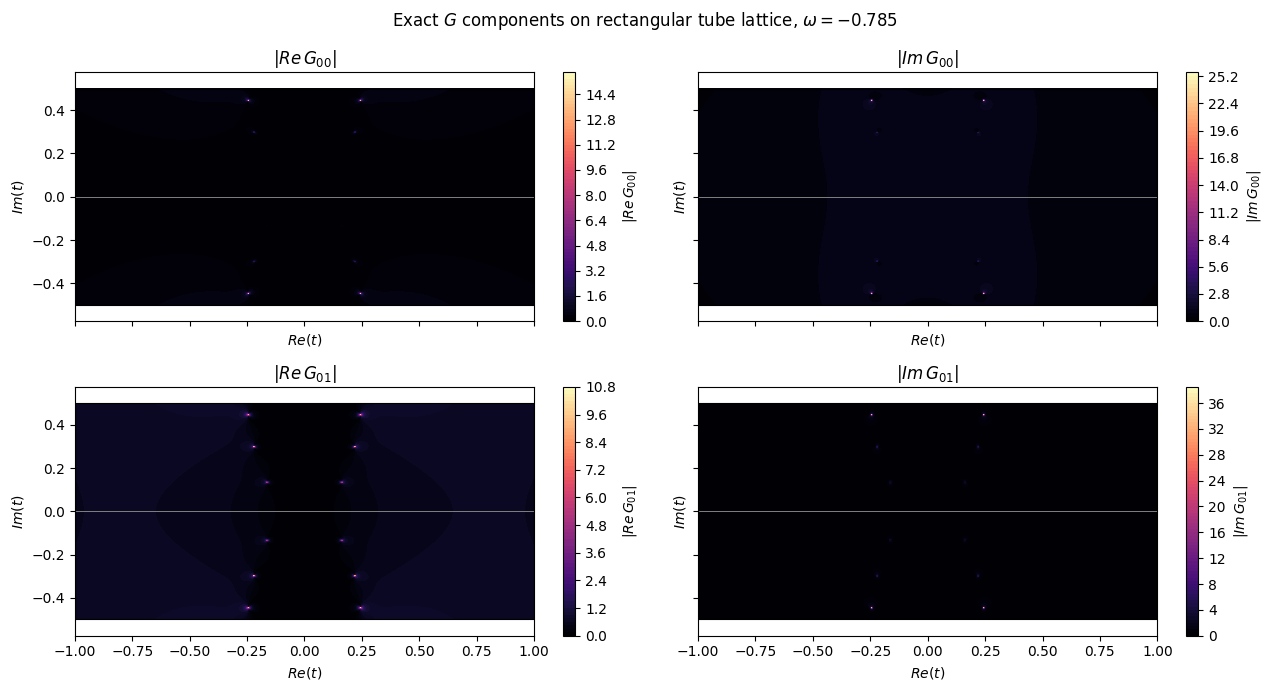

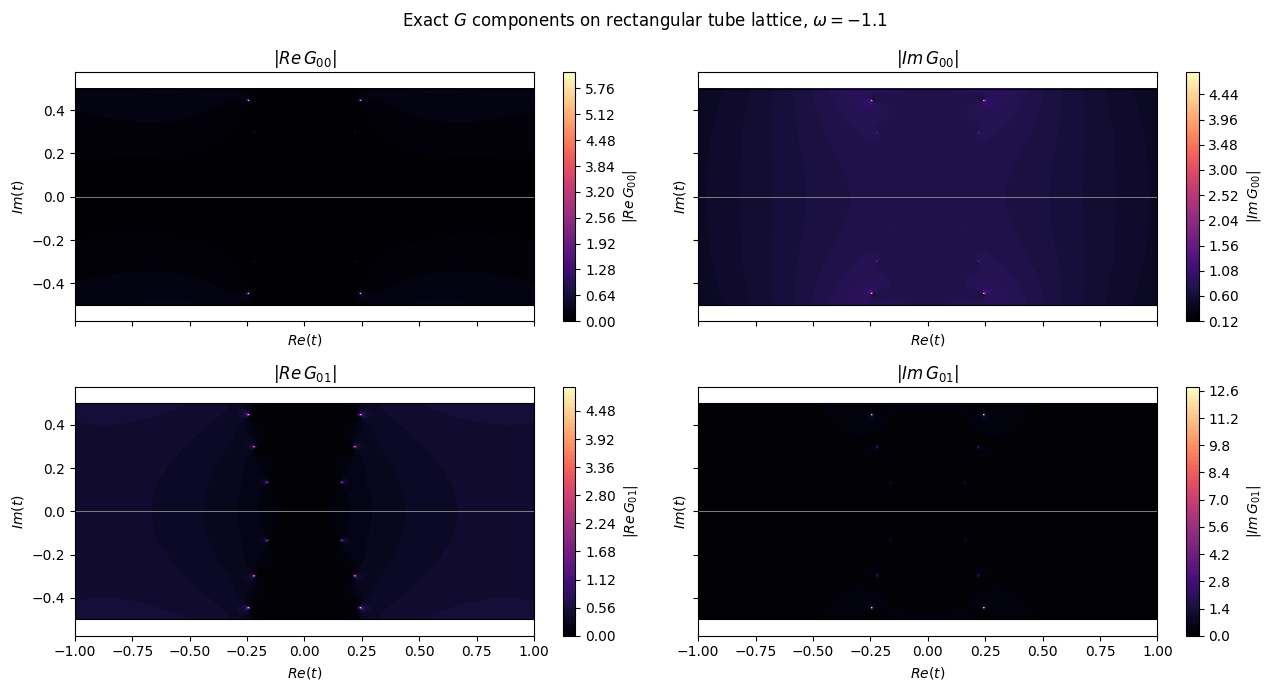

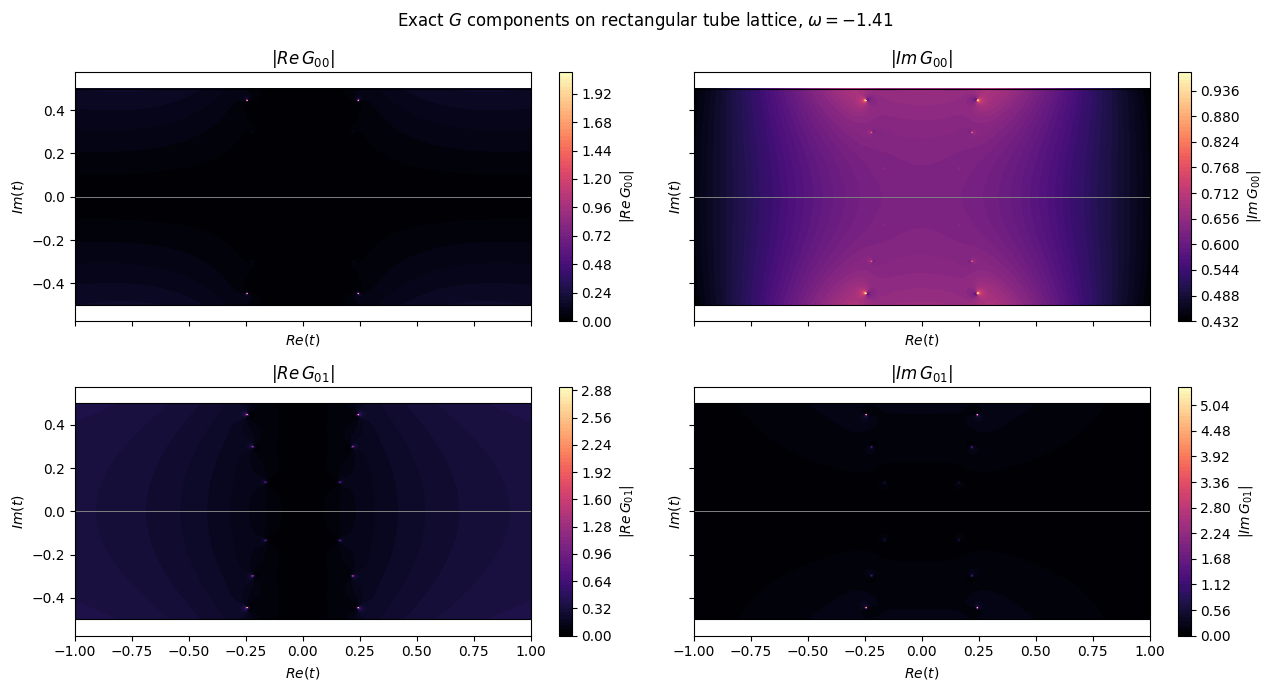

In [12]:
# Optional: inspect selected frequencies for |Re G_00|, |Im G_00|, |Re G_01|, and |Im G_01|.
for n in wn_id:
    fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
    for ax, (i, j, part, title) in zip(axes.ravel(), components):
        values = np.abs(part(G_exact_lattice[:, n, i, j]))
        field = lattice_field(values, tube_mask)
        cf = ax.contourf(real_grid, imag_grid, field, levels=80, cmap="magma")
        ax.plot(boundary.real, boundary.imag, color="k", linewidth=0.8)
        ax.axhline(0, color="0.5", linewidth=0.7)
        ax.set_ylim(-1.15 * tube_delta, 1.15 * tube_delta)
        ax.set_title(title)
        ax.set_xlabel(r"$Re(t)$")
        ax.set_ylabel(r"$Im(t)$")
        fig.colorbar(cf, ax=ax, label=title)

    fig.suptitle(rf"Exact $G$ components on rectangular tube lattice, $\omega={wn[n]:.3g}$")
    fig.tight_layout()
    plt.show()
